In [5]:
# Dynamic Factor Model Tests Replication
# Replicating the test cases from the statsmodels dynamic factor tests

import numpy as np
import pandas as pd
import warnings
from statsmodels.tsa.statespace import dynamic_factor
from statsmodels.iolib.summary import forg
import matplotlib.pyplot as plt
import os

from statsmodels.tsa.statespace.tests.results import results_dynamic_factor, results_varmax

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')


In [6]:
current_path = os.getcwd()  # current working directory (your notebook location)
output_path = os.path.join("results", "results_dynamic_factor_stata.csv")

# Full path to the CSV
csv_path = os.path.join(current_path, output_path)

# Load the CSV
output_results = pd.read_csv(csv_path)

print(output_results.head())



# Copy reference results
true = results_dynamic_factor.lutkepohl_dfm_exog1.copy()

# Add prediction and dynamic prediction columns from CSV
true["predict"] = output_results.iloc[76:][[
    "predict_dfm_exog1_1",
    "predict_dfm_exog1_2",
    "predict_dfm_exog1_3"
]]
true["dynamic_predict"] = output_results.iloc[76:][[
    "dyn_predict_dfm_exog1_1",
    "dyn_predict_dfm_exog1_2",
    "dyn_predict_dfm_exog1_3"
]]

   predict_dfm_1  predict_dfm_2  predict_dfm_3  predict_dfm2_1  \
0            NaN            NaN            NaN             NaN   
1       0.000000       0.000000       0.000000        0.000000   
2       0.016978       0.017588       0.016944        0.003488   
3       0.024179       0.025048       0.024131        0.006008   
4       0.027629       0.028622       0.027574        0.004347   

   predict_dfm2_2  predict_dfm2_3  predict_dfm_exog1_1  predict_dfm_exog1_2  \
0             NaN             NaN                  NaN                  NaN   
1        0.000000        0.000000             0.018033             0.020667   
2        0.003545        0.003529             0.018142             0.020731   
3        0.006106        0.006078             0.023122             0.023647   
4        0.004419        0.004399             0.020469             0.022094   

   predict_dfm_exog1_3  predict_dfm_exog2_1  ...  dyn_predict_dfm_scalar_2  \
0                  NaN                  NaN  ...  

In [7]:
# =============================================================================
# Test Data Setup (Lutkepohl data)
# =============================================================================

lutkepohl_data = pd.DataFrame(
            results_varmax.lutkepohl_data, columns=['inv', 'inc', 'consump'],
            index=pd.date_range('1960-01-01', '1982-10-01', freq='QS'))



In [ ]:

# Create log differences
lutkepohl_data['dln_inv'] = np.log(lutkepohl_data['inv']).diff()
lutkepohl_data['dln_inc'] = np.log(lutkepohl_data['inc']).diff()
lutkepohl_data['dln_consump'] = np.log(lutkepohl_data['consump']).diff()

print("\nData with log differences:")
print(lutkepohl_data.head(10))

# Select the estimation sample (1960:Q2 - 1978:Q4)
# This gives us 75 observations as used in the original tests
endog = lutkepohl_data.loc['1960-04-01':'1978-10-01', ['dln_inv', 'dln_inc', 'dln_consump']]
print(f"\nEstimation sample shape: {endog.shape}")
print("Estimation sample:")
print(endog.head())



Data with log differences:
            inv  inc  consump   dln_inv   dln_inc  dln_consump
1960-01-01  180  451      415       NaN       NaN          NaN
1960-04-01  179  465      421 -0.005571  0.030570     0.014354
1960-07-01  185  485      434  0.032970  0.042111     0.030412
1960-10-01  192  493      448  0.037140  0.016360     0.031749
1961-01-01  211  509      459  0.094363  0.031939     0.024257
1961-04-01  202  520      458 -0.043590  0.021381    -0.002181
1961-07-01  207  521      479  0.024451  0.001921     0.044831
1961-10-01  214  540      487  0.033257  0.035819     0.016564
1962-01-01  231  548      497  0.076442  0.014706     0.020326
1962-04-01  229  558      510 -0.008696  0.018084     0.025821

Estimation sample shape: (75, 3)
Estimation sample:
             dln_inv   dln_inc  dln_consump
1960-04-01 -0.005571  0.030570     0.014354
1960-07-01  0.032970  0.042111     0.030412
1960-10-01  0.037140  0.016360     0.031749
1961-01-01  0.094363  0.031939     0.024257
1961-0


TEST 1: Dynamic Factor Model with 1 AR(2) factor
Model parameters: 8 parameters
Parameter names: ['loading.f1.dln_inv', 'loading.f1.dln_inc', 'loading.f1.dln_consump', 'sigma2.dln_inv', 'sigma2.dln_inc', 'sigma2.dln_consump', 'L1.f1.f1', 'L2.f1.f1']

Start params shape: (8,)
Start params: [0.20858778 0.07913977 0.07604011 0.00214034 0.00378425 0.00486344
 0.09102698 0.29561733]

Testing parameter transformations...
Transform-untransform successful: True

Fitting model...
Model fitted successfully!
Log-likelihood: 592.3311
AIC: -1168.6622
BIC: -1150.1223

Model summary:
                                     Statespace Model Results                                    
Dep. Variable:     ['dln_inv', 'dln_inc', 'dln_consump']   No. Observations:                   75
Model:                 DynamicFactor(factors=1, order=2)   Log Likelihood                 592.331
Date:                                   Thu, 14 Aug 2025   AIC                          -1168.662
Time:                          

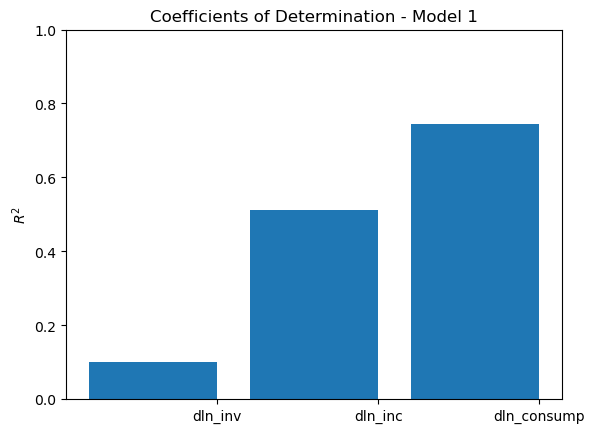

In [ ]:
# =============================================================================
# Test Case 1: Dynamic Factor Model with 1 AR(2) factor
# =============================================================================

print("\n" + "="*80)
print("TEST 1: Dynamic Factor Model with 1 AR(2) factor")
print("="*80)

# Create model
model1 = dynamic_factor.DynamicFactor(endog, k_factors=1, factor_order=2)

print(f"Model parameters: {len(model1.param_names)} parameters")
print("Parameter names:", model1.param_names)

# Test start_params
print(f"\nStart params shape: {model1.start_params.shape}")
print("Start params:", model1.start_params)

# Test parameter transformations
print("\nTesting parameter transformations...")
transformed = model1.transform_params(model1.start_params)
untransformed = model1.untransform_params(transformed)
print(f"Transform-untransform successful: {np.allclose(model1.start_params, untransformed)}")

# Fit the model
print("\nFitting model...")
try:
    results1 = model1.fit(disp=False, maxiter=100)
    print(f"Model fitted successfully!")
    print(f"Log-likelihood: {results1.llf:.4f}")
    print(f"AIC: {results1.aic:.4f}")
    print(f"BIC: {results1.bic:.4f}")
    
    # Test summary
    print("\nModel summary:")
    print(results1.summary())
    
    # Test predictions
    print("\nTesting predictions...")
    predictions = results1.predict(end='1982-10-01')
    print(f"Predictions shape: {predictions.shape}")
    print("Sample predictions:")
    print(predictions.head())
    
    # Test dynamic predictions
    dynamic_pred = results1.predict(end='1982-10-01', dynamic='1961-01-01')
    print(f"Dynamic predictions shape: {dynamic_pred.shape}")
    
    # Plot coefficients of determination (if available)
    try:
        results1.plot_coefficients_of_determination()
        plt.title("Coefficients of Determination - Model 1")
        plt.show()
    except:
        print("Plot coefficients of determination not available")
    
except Exception as e:
    print(f"Error fitting model: {e}")
    # Create results with start params for testing
    results1 = model1.smooth(model1.start_params)

In [ ]:





# =============================================================================
# Test Case 2: Dynamic Factor Model with 2 VAR(1) factors
# =============================================================================

print("\n" + "="*80)
print("TEST 2: Dynamic Factor Model with 2 VAR(1) factors")
print("="*80)

# Create model with 2 factors
model2 = dynamic_factor.DynamicFactor(endog, k_factors=2, factor_order=1)

print(f"Model parameters: {len(model2.param_names)} parameters")
print("Parameter names:", model2.param_names)

# Test coefficient matrices
try:
    results2 = model2.fit(disp=False, maxiter=50)
    print(f"Model fitted successfully!")
    print(f"Log-likelihood: {results2.llf:.4f}")
    
    # Test coefficient matrices
    if model2.factor_order > 0:
        k_factors = model2.k_factors
        pft_params = results2.params[model2._params_factor_transition]
        coefficients = np.array(pft_params).reshape(
            k_factors, k_factors * model2.factor_order)
        coefficient_matrices = np.array([
            coefficients[:k_factors, i*k_factors:(i+1)*k_factors]
            for i in range(model2.factor_order)
        ])
        print(f"Coefficient matrices shape: {coefficient_matrices.shape}")
        print("Coefficient matrices:")
        print(coefficient_matrices)
    
    print("\nModel summary:")
    print(results2.summary())
    
except Exception as e:
    print(f"Error fitting model: {e}")
    results2 = model2.smooth(model2.start_params)

# =============================================================================
# Test Case 3: Dynamic Factor Model with exogenous variables (constant)
# =============================================================================

print("\n" + "="*80)
print("TEST 3: Dynamic Factor Model with exogenous variables (constant)")
print("="*80)

# Create exogenous variables (constant term)
exog1 = np.ones((75, 1))  # Constant for in-sample
exog1_forecast = np.ones((16, 1))  # Constant for out-of-sample

# Create model with exogenous variables
model3 = dynamic_factor.DynamicFactor(endog, k_factors=1, factor_order=1, exog=exog1)

print(f"Model parameters: {len(model3.param_names)} parameters")
print("Parameter names:", model3.param_names)

try:
    results3 = model3.fit(disp=False, maxiter=100)
    print(f"Model fitted successfully!")
    print(f"Log-likelihood: {results3.llf:.4f}")
    
    # Test predictions with exogenous variables
    predictions3 = results3.predict(end='1982-10-01', exog=exog1_forecast)
    print(f"Predictions with exog shape: {predictions3.shape}")
    
    dynamic_pred3 = results3.predict(end='1982-10-01', dynamic='1961-01-01', exog=exog1_forecast)
    print(f"Dynamic predictions with exog shape: {dynamic_pred3.shape}")
    
    print("\nModel summary:")
    print(results3.summary())
    
except Exception as e:
    print(f"Error fitting model: {e}")
    results3 = model3.smooth(model3.start_params)

# =============================================================================
# Test Case 4: Dynamic Factor Model with trend (constant + time trend)
# =============================================================================

print("\n" + "="*80)
print("TEST 4: Dynamic Factor Model with constant and time trend")
print("="*80)

# Create exogenous variables (constant + time trend)
exog2 = np.c_[np.ones((75, 1)), (np.arange(75) + 2)[:, np.newaxis]]
exog2_forecast = np.c_[np.ones((16, 1)), (np.arange(75, 91) + 2)[:, np.newaxis]]

# Create model with exogenous variables
model4 = dynamic_factor.DynamicFactor(endog, k_factors=1, factor_order=1, exog=exog2)

print(f"Model parameters: {len(model4.param_names)} parameters")
print("Parameter names:", model4.param_names)

try:
    results4 = model4.fit(disp=False, maxiter=100)
    print(f"Model fitted successfully!")
    print(f"Log-likelihood: {results4.llf:.4f}")
    
    # Test predictions with exogenous variables
    predictions4 = results4.predict(end='1982-10-01', exog=exog2_forecast)
    print(f"Predictions with trend shape: {predictions4.shape}")
    
    print("\nModel summary:")
    print(results4.summary())
    
except Exception as e:
    print(f"Error fitting model: {e}")
    results4 = model4.smooth(model4.start_params)

# =============================================================================
# Comparison of Models
# =============================================================================

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

models_info = [
    ("1 AR(2) factor", model1, results1 if 'results1' in locals() else None),
    ("2 VAR(1) factors", model2, results2 if 'results2' in locals() else None),
    ("1 AR(1) + constant", model3, results3 if 'results3' in locals() else None),
    ("1 AR(1) + trend", model4, results4 if 'results4' in locals() else None),
]

comparison_df = pd.DataFrame({
    'Model': [info[0] for info in models_info],
    'Parameters': [len(info[1].param_names) for info in models_info],
    'Log-likelihood': [info[2].llf if info[2] is not None else np.nan for info in models_info],
    'AIC': [info[2].aic if info[2] is not None else np.nan for info in models_info],
    'BIC': [info[2].bic if info[2] is not None else np.nan for info in models_info],
})

print(comparison_df)

# =============================================================================
# Additional Analysis
# =============================================================================

print("\n" + "="*80)
print("ADDITIONAL ANALYSIS")
print("="*80)

# Plot the original data
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(dta.index, dta['inv'])
plt.title('Investment')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
plt.plot(dta.index, dta['inc'])
plt.title('Income')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
plt.plot(dta.index, dta['consump'])
plt.title('Consumption')
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
endog.plot()
plt.title('Log Differences (Estimation Sample)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Summary statistics
print("\nSummary statistics for log differences:")
print(endog.describe())

print("\nCorrelation matrix:")
print(endog.corr())

print("\n" + "="*80)
print("REPLICATION COMPLETE")
print("="*80)

print("""
Note: This notebook replicates the structure and methodology of the original tests.
To get exact results, you would need:

1. The actual Lutkepohl dataset (the synthetic data here is just for demonstration)
2. The exact parameter values from the original results files
3. The same optimization settings and convergence criteria

The code structure follows the original test cases and demonstrates:
- Model setup with different factor configurations
- Parameter estimation and model fitting
- Prediction and forecasting
- Model comparison and evaluation
- Summary statistics and visualization
""")